#### Notebook GeoTiff to Cloud-Optimzed GeoTiff

Goal: Show how a GeoTiff is converted to a COG

Steps:
- downlaod img into local storage using stac -> S1 VV and VH
- convert to COG using xarray and rasterio
- compare data access, windowed reading (xr and rio)
- show img pyramids


In [27]:
import xarray as xr
import rioxarray
import pystac_client
import requests
import rasterio
import time

from rasterio.windows import Window
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from typing import List, Dict
from timeit import timeit

from rasterio.io import MemoryFile

from rio_cogeo.cogeo import cog_validate
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles

import numpy as np
import pandas as pd

In [28]:
datapath = Path('../data/01_S1_sigma0_geotif')
cog_path = Path('../outputs/01_S1_sigma0_cog')

datapath.mkdir(parents=True, exist_ok=True)
cog_path.mkdir(parents=True, exist_ok=True)

In [29]:
def get_img(outpath: Path, collection: str, item_id: str):

    stac_url = "https://stac.eodc.eu/api/v1/"
    eodc = pystac_client.Client.open(stac_url)
    item = eodc.get_collection(collection).get_item(id=item_id)

    if item:
        for asset_key, asset in item.assets.items():
            fn = f'{item.id}_{asset_key}.tif'

            if 'thumbnail' in asset_key:
                continue

            response = requests.get(asset.href, stream=True)

            with open(outpath / fn, "wb") as f:
                for chunk in tqdm(response.iter_content(chunk_size=8192), desc=f"  Downloading {fn}"):
                    f.write(chunk)

    return


# download the images into the local filesystem
get_img(outpath=datapath, 
        collection='SENTINEL1_SIG0_20M',
        item_id='SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH')

In [30]:
def eval_dir(dp: Path) -> Dict[str, bool]:
    valid = {}
    for fn in dp.glob('*.tif'):
        is_valid, errors, warnings = cog_validate(fn, quiet=True)
        valid[str(fn)] = is_valid
        print(f'Valid COG: {is_valid}, file: {fn}')
        for error in errors:
            print(f'    {error}')
    
    return valid

# Its possible to evaluate if a GeoTiff is a COG (tiling and (not required) overviews)
res = eval_dir(datapath)

Valid COG: False, file: ../data/01_S1_sigma0_geotif/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif
    The file is greater than 512xH or 512xW, but is not tiled
    The offset of the main IFD should be < 300. It is 102847300 instead
    The offset of the first block of the image should be after its IFD
Valid COG: False, file: ../data/01_S1_sigma0_geotif/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif
    The file is greater than 512xH or 512xW, but is not tiled
    The offset of the main IFD should be < 300. It is 95457940 instead
    The offset of the first block of the image should be after its IFD


##### Conversion

Different methods can be used to convert a GeoTiff to a COG:
- rio_cogeo package with rasterio: rewrites the raster with blocksizes (-> add tiling) and overview_levels (-> add iamge pyramids)
- xarray with rioxarray: rewrites the raster with similar settings, but less code overhead as its handled by xarray

Both of these packages wrap arounf gdal_translate so the processe in the background are the same. Its important to consider dtypes, masking, and scaling as they are implemented/applied differntly in rasterio and xarray. As we can see in the checks below, both adhere to the COG specification, but xarray works slighly faster (maybe due to parallel processing in the overview generation by dask arrays compared to rasterio).

In [31]:
%%time
# convert to COG with rasterio
# https://guide.cloudnativegeo.org/cloud-optimized-geotiffs/writing-cogs-in-python.html

for fn in datapath.glob('*.tif'):
    print(f'Converting (rio_cogeo) {fn}')
    new_fn = cog_path / str('rio_cogeo' + str(fn.name))
    
    with rasterio.open(fn, 'r') as src:
        # initialise meta parameters to add overviews
        src_profile = src.profile
        
        # init a memoryfile to write data into
        with MemoryFile() as memfile:
            with memfile.open(**src_profile) as mem:
                # write single band information -> adapt for multi-band use cases where you might not want towrite everything
                mem.write(src.read())

                # the COG conversion magic happens here: recommendations are ZSTD, LZW, deflate for compression
                dst_profile = cog_profiles.get("ZSTD")

                # this is very important as the cog_profile assumes float32, which is not the case for S1 as its saved with int16 to reduce storage
                dst_profile.update({'dtype': src_profile['dtype']})

                # These profile parameters are set which annotate the raster and allow the optimised windowed reading
                
                # "driver": "GTiff",
                # "interleave": "pixel",
                # "tiled": True,
                # "blockxsize": 512, 
                # "blockysize": 512,
                # "compress": "DEFLATE",

                # Creating destination COG
                cog_translate(
                    mem,
                    new_fn,
                    dst_profile,
                    use_cog_driver=True,
                    in_memory=False,
                    overview_level=4,
                    overview_resampling='nearest',
                    nodata=src.nodata,  # or with another newly defined nodata
                    quiet=True
                )


Converting (rio_cogeo) ../data/01_S1_sigma0_geotif/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif


/home/samuel/coding/cn_datacube_notebooks/.venv/lib/python3.12/site-packages/rio_cogeo/profiles.py:182: UserWarning: Non-standard compression schema: zstd. The output COG might not be fully supported by software not build against latest libtiff.
  warnings.warn(
<timed exec>:34: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.


Converting (rio_cogeo) ../data/01_S1_sigma0_geotif/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif
CPU times: user 16.6 s, sys: 2.76 s, total: 19.3 s
Wall time: 21 s


In [32]:
# convert to COG with xarray
%time

# convert to COG with rioxarray
for fn in datapath.glob('*.tif'):
    print(f'Converting (xarray) {fn}')
    new_fn = cog_path / str('xarray' + str(fn.name))

    da = rioxarray.open_rasterio(fn)  # do not provide mask_and_scale=True to maintin int16

    da[0].rio.to_raster(
        new_fn,
        compress="ZSTD",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        overview_count=4,
        overview_resampling='nearest',
        driver='COG',
        dtype=da.dtype, # set explicitly if required by data type -> eg S1 
    )

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 5.01 μs
Converting (xarray) ../data/01_S1_sigma0_geotif/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif
Converting (xarray) ../data/01_S1_sigma0_geotif/SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif


In [33]:
# Check if the COGS have been created succesfully
results = eval_dir(cog_path)

Valid COG: True, file: ../outputs/01_S1_sigma0_cog/rio_cogeoSIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif
Valid COG: True, file: ../outputs/01_S1_sigma0_cog/xarraySIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif
Valid COG: True, file: ../outputs/01_S1_sigma0_cog/xarraySIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif
Valid COG: True, file: ../outputs/01_S1_sigma0_cog/rio_cogeoSIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif


In [34]:
# benchmarking functions to test read speed for GeoTiff and COG
def itimg(img: rasterio.DatasetReader, window_size: int) -> None:
    nlat, nlon = img.shape
    for ilat in range(0, nlat, window_size):
        for ilon in range(0, nlon, window_size):
            #img.isel(y=slice(ilat, min(ilat + window_size, nlat)), x=slice(ilon, min(ilon + window_size, nlon))).load()
            img.read(1, window=Window(*[ilon, ilat, min(window_size, nlon - ilon), min(window_size, nlat - ilat)]))

    return None

def itrndimg(img: rasterio.DatasetReader) -> None:
    rng = np.random.default_rng(42)
    row = rng.integers(0, img.height - 256)
    col = rng.integers(0, img.width - 256)

    img.read(1, window=Window(*[col, row, 256, 256]))

    return None


def benchmark_tif(fn: Path) -> Dict:
    vals = {}
    
    # file size
    fsize = fn.stat().st_size
    vals['filesize'] = fsize

    with rasterio.open(fn) as src:
        
        # iterate over whole array in window size x
        for x in [256, 512, 1048]:
            t_win = timeit(
                lambda: itimg(src, x), # type: ignore
                number=10,
            )
            vals[f'window_{x}_access'] = round(t_win, 6)

        # add overview reading
        for factor in [2, 4, 8]:
            t = timeit(
                lambda: src.read(
                    1,
                    out_shape=(
                        src.height // factor,
                        src.width // factor,
                    ),
                    resampling=rasterio.enums.Resampling.nearest, # type: ignore
                ),
                number=100,
            )
            vals[f'overview_{factor}_access'] = round(t, 6)


    return vals

ress = {}

for fn in datapath.glob('*.tif'):
    res = benchmark_tif(fn)
    ress[fn.name] = res

for fn in cog_path.glob('xarray*.tif'):
    res = benchmark_tif(fn)
    ress[fn.name] = res

for file, results in ress.items():
    print(file)
    print(results)

/tmp/ipykernel_43630/2481854672.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  img.read(1, window=Window(*[ilon, ilat, min(window_size, nlon - ilon), min(window_size, nlat - ilat)]))
/tmp/ipykernel_43630/2481854672.py:41: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lambda: src.read(


SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif
{'filesize': 102873428, 'window_256_access': 0.951927, 'window_512_access': 0.441498, 'window_1048_access': 0.33571, 'overview_2_access': 3.002682, 'overview_4_access': 0.897865, 'overview_8_access': 0.425956}
SIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif
{'filesize': 95484068, 'window_256_access': 0.875285, 'window_512_access': 0.428829, 'window_1048_access': 0.321693, 'overview_2_access': 2.793666, 'overview_4_access': 0.890975, 'overview_8_access': 0.35552}
xarraySIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VV.tif
{'filesize': 122480356, 'window_256_access': 0.734341, 'window_512_access': 0.276046, 'window_1048_access': 0.277361, 'overview_2_access': 1.578533, 'overview_4_access': 0.273851, 'overview_8_access': 0.030591}
xarraySIG0_20260624T060724_D008_E039N015T3_EU020M_V1M2R3_S1DIWGRDH_VH.tif
{'filesize': 131194821, 'window_256_access': 0.673575, 'window_512_access': 0.252254, 

These benchmarks show the following insights:
- coverting to COG increases the file size due to the added overviews
- windowed reading in COGs is faster as less information has to be read in. The biggest comparative boost comes from reading with 512*512 windows, as that matches the defined block/chunksize of the COG
- reading in overviews instead of computing them in memory is much faster

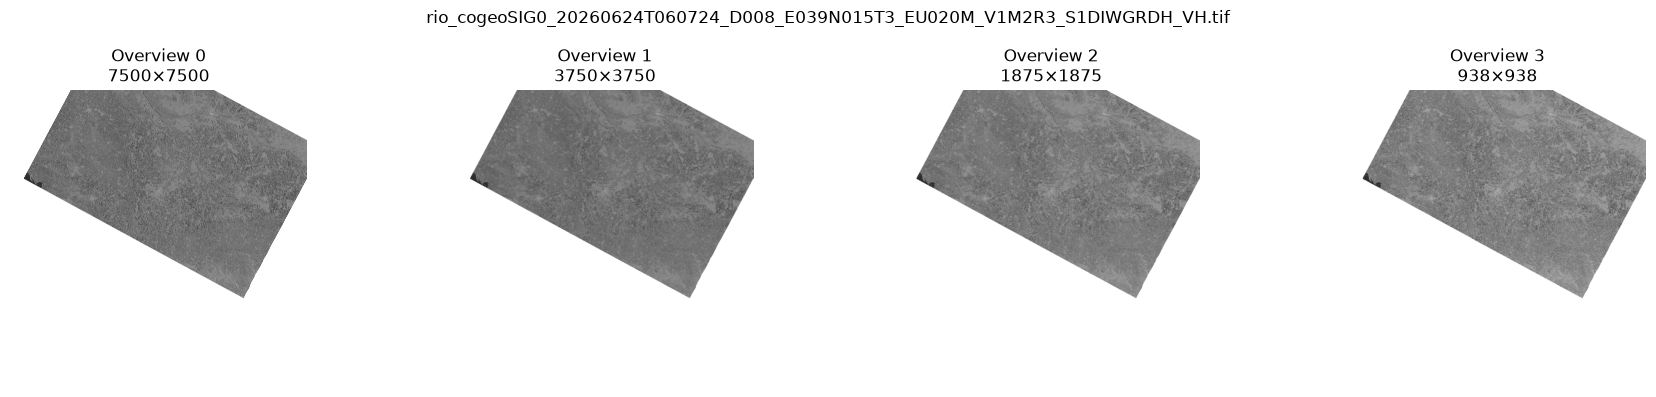

In [35]:
# show overviews -> very easy to plot :) but not really required at all
for fn in cog_path.glob('*.tif'):
    overview_lvls = [0, 1, 2, 3]
    arrays = []
    for view in overview_lvls:
        with rasterio.open(fn, overview_level=view) as src:
            arr = src.read()[0]
            arr = arr.astype(np.float32)
            arr[arr==-9999] = np.nan
            arrays.append(arr)

    fig, axes = plt.subplots(1, len(arrays), figsize=(18, 4))

    for ax, arr, level in zip(axes, arrays, overview_lvls):
        ax.imshow(arr, cmap="gray")
        ax.set_title("Full res" if level == -1 else f"Overview {level}\n{arr.shape[1]}×{arr.shape[0]}")
        ax.axis("off")

    fig.suptitle(fn.name)
    plt.tight_layout()
    plt.show()
    break
